Number of input files: 247
Dataset created, counting MIDI notes...
This may take a while...


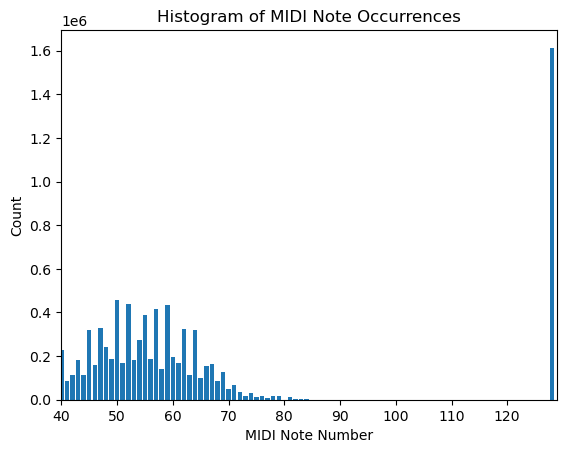

Filtered dataset created, counting MIDI notes again...


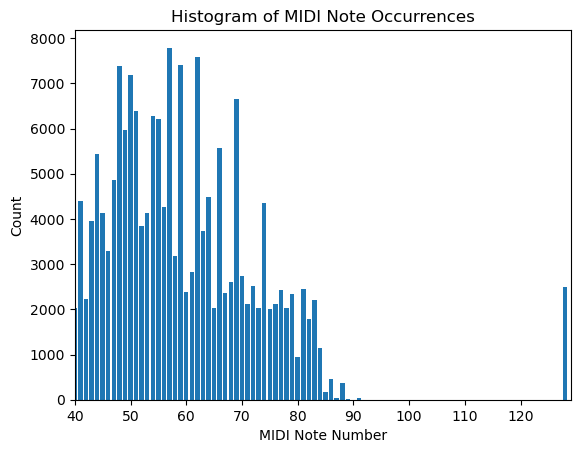

Filtered dataset written to /home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset/filtered_data.tfrecord


I0000 00:00:1770746024.590196  757931 local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
import numpy as np
import os,glob
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from common import OUTPUT_DIM_NOTES
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'

training_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices'
subset = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset'

input_filepaths = sorted(glob.glob(os.path.join(training_dir, '**', 'input', 'data.tfrecord'), recursive=True))
random.seed(42)
random.shuffle(input_filepaths)
# input_filepaths=input_filepaths[:1000]
feature_description = {
    "input":  tf.io.FixedLenFeature([], tf.string),
    "output": tf.io.FixedLenFeature([], tf.string),
}


print(f'Number of input files: {len(input_filepaths)}')

# tf.py_function that creates a histogram of MIDI note occurrences from the label data in the TFRecord files
def createhist(labels):
    hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    output_data = labels.numpy()  # Reshape to (num_frames, 89)
    for note in range(OUTPUT_DIM_NOTES):
        if output_data[note] == 1:
            hist[note] += 1
    return hist

# Read the label data from the TFRecord files and create a histogram of MIDI note occurrences
def parse_tfrecord(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    audio = tf.io.decode_raw(parsed["input"], tf.float32)
    label = tf.io.decode_raw(parsed["output"], tf.int8)
    # hist = tf.py_function(createhist, [label], tf.int32)
    return audio,label

def create_dataset(filepaths):
    dataset = tf.data.TFRecordDataset(filepaths)
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    dataset=dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

def count_midi_notes(dataset):
    # hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    initial_state = tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32)
    
    # 2. Define the reduction function
    # 'old_state' is the current sum, 'next_element' is (features, labels)
    def reduce_fn(old_state, next_element):
        _, labels = next_element
        # Cast labels to int32 to match state and prevent overflow
        return old_state + tf.cast(labels, tf.int32)

    # 3. Perform the reduction
    # This happens in the TF graph and is memory-efficient
    hist = dataset.reduce(initial_state, reduce_fn)
    
    return hist.numpy()

def plot_histogram(hist):
    plt.bar(range(OUTPUT_DIM_NOTES), hist)
    plt.xlabel('MIDI Note Number')
    plt.ylabel('Count')
    plt.title('Histogram of MIDI Note Occurrences')
    plt.xlim(40, OUTPUT_DIM_NOTES)  # Limit x-axis to the range of interest
    plt.show()

dataset = create_dataset(input_filepaths)
print("Dataset created, counting MIDI notes...")
print("This may take a while...")

midi_histogram = count_midi_notes(dataset)
plot_histogram(midi_histogram)

note_count_maximum = 100000#0.2*10**6
# Create dataset in which each note is limited to a maximum count of note_count_maximum by filtering out samples with that note until the count is below the maximum
def filter_notes(hist):
    def filter_fn(labels):

        #print shape of hist_part
        #print("Shape of histogram part:", hist_part.shape)
        result=np.ones((1,), dtype=bool)[0]
        # hist=hist+labels

        for note in range(OUTPUT_DIM_NOTES):
            hist[note]+=labels[note]
            # if labels[note] == 1:
            #     if hist[note] >= note_count_maximum: 
            #         result=False
        # assert labels[OUTPUT_DIM_NOTES-1]==0
        
        # Check the minimum count for notes that are present in the current sample
        masks = labels == 1
        #print("Mask for current sample:", masks)
        min_count = np.min(hist[masks]) if np.any(masks) else 0
        # print("Current histogram:", hist)
        # print("Min count for current sample:", min_count)
        # if min_count>0:
        #     print("Minimum count for notes with occurrences:", min_count)
        if min_count >= note_count_maximum:
            #print("Minimum count reached for all notes, stopping filtering: ", min_count)
            result=False
        return result
    filter_function = lambda _,labels: tf.numpy_function(filter_fn, [labels], tf.bool)
    return filter_function

# Create a new dataset with the filtered samples
midi_histogram= np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
filtered_dataset = dataset.filter(filter_notes(midi_histogram))
# print("Length of filtered dataset:", len(filtered_dataset))
print("Filtered dataset created, counting MIDI notes again...")
filtered_midi_histogram = count_midi_notes(filtered_dataset)
plot_histogram(filtered_midi_histogram)

# Write the audio and label data of the filtered dataset to new TFRecord files
def _bytes_feature(value: bytes) -> tf.train.Feature:
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))
def serialize_example(input: np.ndarray, output: np.ndarray) -> bytes:
    feature = {
        "input":  _bytes_feature(input.tobytes()),
        "output": _bytes_feature(output.tobytes()),
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example.SerializeToString()
def write_tfrecord(dataset, output_filepath):
    with tf.io.TFRecordWriter(output_filepath) as writer:
        for audio, label in dataset:
            
            example = serialize_example(audio.numpy(), label.numpy())
            writer.write(example)

#Create output directory if it doesn't exist
os.makedirs(subset, exist_ok=True)

output_filepath = os.path.join(subset, 'filtered_data.tfrecord')
write_tfrecord(filtered_dataset, output_filepath)
print(f"Filtered dataset written to {output_filepath}")





In [3]:
#EDIT: THIS PART HAS MOVED TO TRAINING.IPYNB!

# # The limit of samples with midi notes off to be put into the trainingset
# sailent_thresh=20000 
# current_sailent_count=np.zeros(89,dtype=int)
# selected_outfiles=[]
# selected_infiles=[]
 
# rng=np.random.default_rng(123)
# perm=rng.permutation(len(output_filepaths))
# output_filepaths=[output_filepaths[i] for i in perm]
# input_filepaths=[input_filepaths[i] for i in perm]
# # for i,output_filepath in enumerate(output_filepaths):
# #     output_data=np.load(output_filepath)


#     # # print(output_data.shape)
#     # # print("out path:", output_filepath)
#     # # print("in path:", input_filepaths[i])
#     # if output_data[0][88]>0:
#     #     if current_sailent_count[88]<sailent_thresh:
#     #         selected_outfiles.append(output_filepath)
#     #         selected_infiles.append(input_filepaths[i])
#     #         current_sailent_count[88]+=1
#     # else:
#     #     selected_outfiles.append(output_filepath)
#     #     selected_infiles.append(input_filepaths[i])


# for i,output_filepath in enumerate(output_filepaths):
#     output_data=np.load(output_filepath)
#     copydata=True
#     for note in range(89):
#         if output_data[0][note]>0:
#             if current_sailent_count[note]>sailent_thresh:
#                 copydata=False

#     # print(output_data.shape)
#     # print("out path:", output_filepath)
#     # print("in path:", input_filepaths[i])

#     if copydata:
#         selected_outfiles.append(output_filepath)
#         selected_infiles.append(input_filepaths[i])
#         for note in range(89):
#             if output_data[0][note]>0:
#                 current_sailent_count[note]+=1
   


In [4]:
# import shutil



# # os.makedirs(trin,exist_ok=True)
# print("Selected files count:",len(selected_outfiles))
# for i,output_filepath in enumerate(selected_outfiles):
   
#     output_filename=os.path.basename(output_filepath)
#     input_filename=os.path.basename(selected_infiles[i])
#     parentdir=os.path.dirname(os.path.dirname(output_filepath))
#     destin_dir=os.path.join(subset,os.path.basename(parentdir))
#     os.makedirs(destin_dir,exist_ok=True)
#     trin=os.path.join(destin_dir,'input')
#     trout=os.path.join(destin_dir,'output')
#     os.makedirs(trin,exist_ok=True)
#     os.makedirs(trout,exist_ok=True)
#     fout=os.path.join(trout,output_filename)
#     fin=os.path.join(trin,input_filename)
#     # print('Copying ',output_filepath,' to ',fout)
#     shutil.copyfile(output_filepath,fout)
    
#     # print('Copying ',selected_infiles[i],' to ',fin)
#     shutil.copyfile(selected_infiles[i],fin)
    

# print("Final midi hist:")
# output_filepaths = sorted(glob.glob(os.path.join(subset, '**', 'output', '*.npy'), recursive=True))
# midi_hist(output_filepaths)


